# LSTM Model Training for OGDC Stock Price Prediction

This notebook trains a deep LSTM model to predict OGDC stock prices using a 60-day lookback window.

## Architecture Overview:
- **Bidirectional LSTM** (100 units) - learns patterns forward and backward
- **Dropout layers** (0.3) - prevents overfitting
- **Stacked LSTM** (100 units) - consolidates features
- **Dense layers** - final prediction

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd
import io
from google.colab import files

print("Please upload 'ogdc_data.csv'...")

# This creates the button
uploaded = files.upload()

# Get the filename (assuming you upload one file)
filename = next(iter(uploaded))

# Load into Pandas
try:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Clean up column names (strip spaces, lowercase)
    df.columns = df.columns.str.strip().str.lower()

    # Sort by date if it exists
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

    print(f"✅ Data loaded successfully! Shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst 5 rows:")
    display(df.head())

except Exception as e:
    print(f"❌ Error loading file: {e}")

Please upload 'ogdc_data.csv'...


Saving ogdc_data_updated.csv to ogdc_data_updated.csv
✅ Data loaded successfully! Shape: (1223, 8)

Columns: ['id', 'ticker', 'date', 'open', 'high', 'low', 'close', 'volume']

First 5 rows:


,id,ticker,date,open,high,low,close,volume
0,235,OGDC,2021-03-01,105.15,105.45,103.40,104.48,993856
1,236,OGDC,2021-03-02,104.00,107.00,103.71,105.40,1627498
2,237,OGDC,2021-03-03,105.99,106.70,104.05,106.22,849105
3,238,OGDC,2021-03-04,103.50,106.00,103.50,104.28,1610733
4,239,OGDC,2021-03-05,106.40,108.40,104.25,107.10,1858659



📊 Close prices shape: (1223, 1)
Price range: 69.77 - 333.90


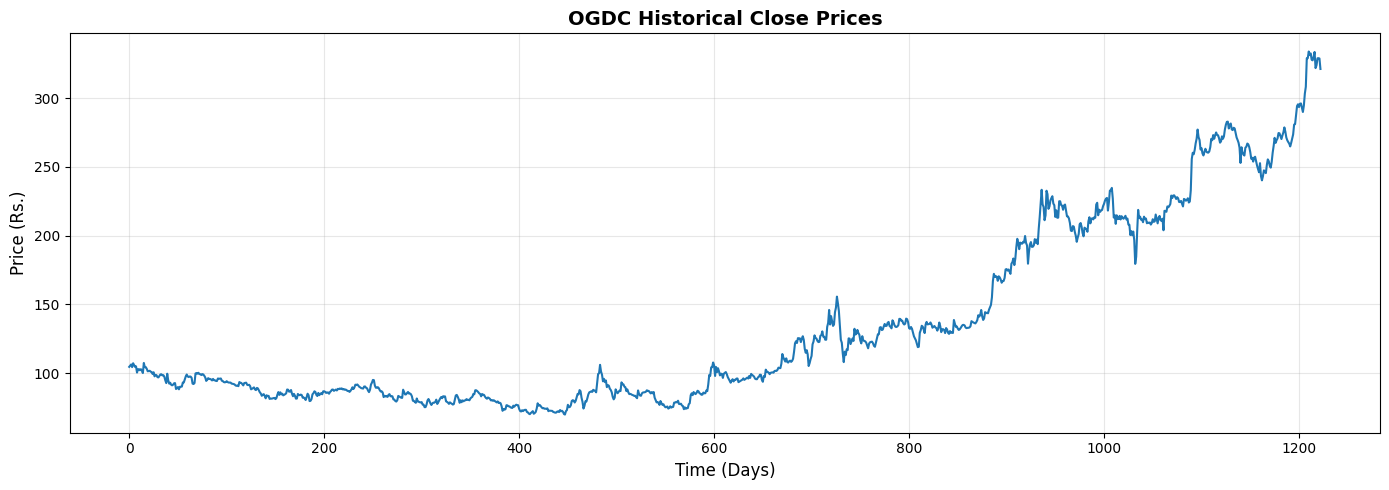


Total data points: 1223


In [3]:
# Data Preprocessing
# Convert date column to datetime if it exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    print("✅ Date column processed and sorted")

# Extract Close prices for prediction
close_prices = df['close'].values.reshape(-1, 1)
print(f"\n📊 Close prices shape: {close_prices.shape}")
print(f"Price range: {close_prices.min():.2f} - {close_prices.max():.2f}")

# Visualize the data
plt.figure(figsize=(14, 5))
plt.plot(close_prices, linewidth=1.5)
plt.title('OGDC Historical Close Prices', fontsize=14, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Price (Rs.)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal data points: {len(close_prices)}")

In [4]:
# Scale the Data (0-1 range)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("✅ Data scaled to range [0, 1]")
print(f"Scaled range: {scaled_data.min():.4f} - {scaled_data.max():.4f}")

✅ Data scaled to range [0, 1]
Scaled range: 0.0000 - 1.0000


In [5]:
# Create 60-Day Lookback Window Training Data
LOOKBACK_WINDOW = 60

X_train = []
y_train = []

for i in range(LOOKBACK_WINDOW, len(scaled_data)):
    X_train.append(scaled_data[i-LOOKBACK_WINDOW:i, 0])  # Past 60 days
    y_train.append(scaled_data[i, 0])                    # Next day (target)

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for LSTM input: [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

print(f"✅ Training data created successfully!")
print(f"X_train shape: {X_train.shape}  (samples, lookback, features)")
print(f"y_train shape: {y_train.shape}")
print(f"\nTotal training samples: {len(X_train)}")

✅ Training data created successfully!
X_train shape: (1163, 60, 1)  (samples, lookback, features)
y_train shape: (1163,)

Total training samples: 1163


In [6]:
# Build Deep LSTM Model
model = Sequential(name="Deep_LSTM_Forecaster")

# Layer 1: Bidirectional LSTM (learns forward + backward patterns)
model.add(Bidirectional(
    LSTM(100, return_sequences=True),
    input_shape=(LOOKBACK_WINDOW, 1)
))
model.add(Dropout(0.3))

# Layer 2: Second LSTM layer to consolidate features
model.add(LSTM(100, return_sequences=False))
model.add(Dropout(0.3))

# Layer 3: Dense layer for feature interpretation
model.add(Dense(25, activation='relu'))

# Output Layer: Single price prediction
model.add(Dense(1))

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print("✅ Model built successfully!\n")
model.summary()

✅ Model built successfully!



Model: "Deep_LSTM_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 200)        │        81,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,551 (799.03 KB)

 Trainable params: 204,551 (799.03 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the Model
print("🚀 Starting training...\n")

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\n✅ Training completed!")

🚀 Starting training...

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0151 - mae: 0.0755 - val_loss: 0.0032 - val_mae: 0.0435
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - mae: 0.0271 - val_loss: 0.0032 - val_mae: 0.0435
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - mae: 0.0223 - val_loss: 0.0015 - val_mae: 0.0298
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - mae: 0.0222 - val_loss: 0.0016 - val_mae: 0.0323
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - mae: 0.0216 - val_loss: 0.0073 - val_mae: 0.0767
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - mae: 0.0212 - val_loss: 0.0035 - val_mae: 0.0476
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.5998e-04 - mae: 0.0198 - val_loss: 0.0036 - val_mae: 0.0489
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6587e-04 - mae: 0.0205 - val_loss: 0.0030 - val_mae: 0.0430
Epoch 9/100
33/33 ━━━━━━

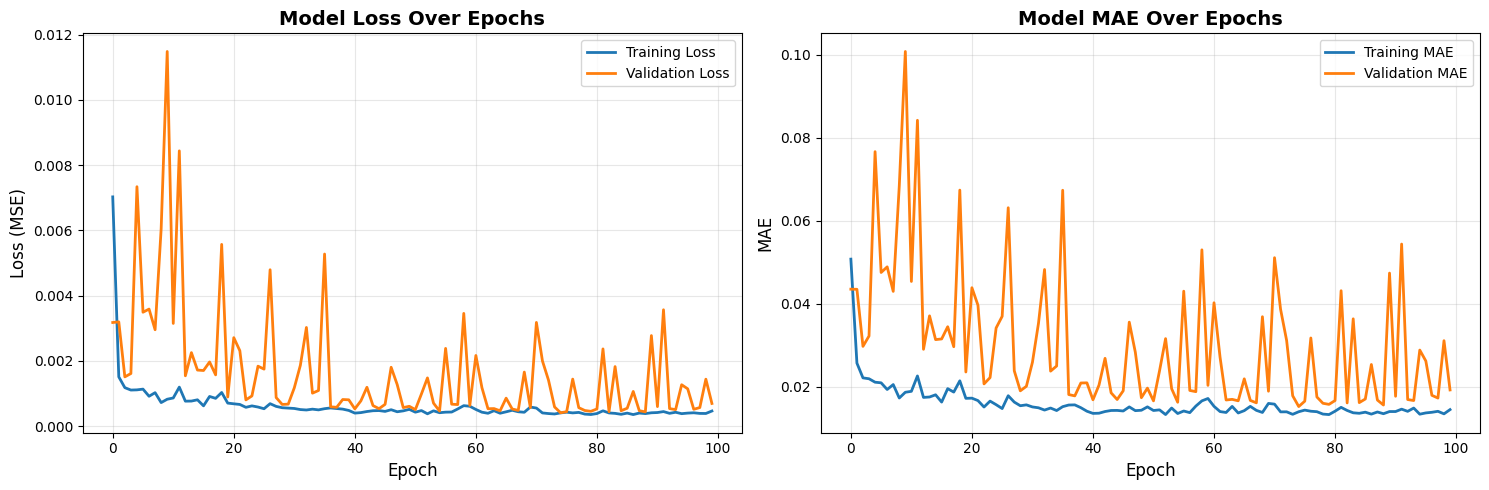

In [8]:
# Visualize Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Model MAE Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


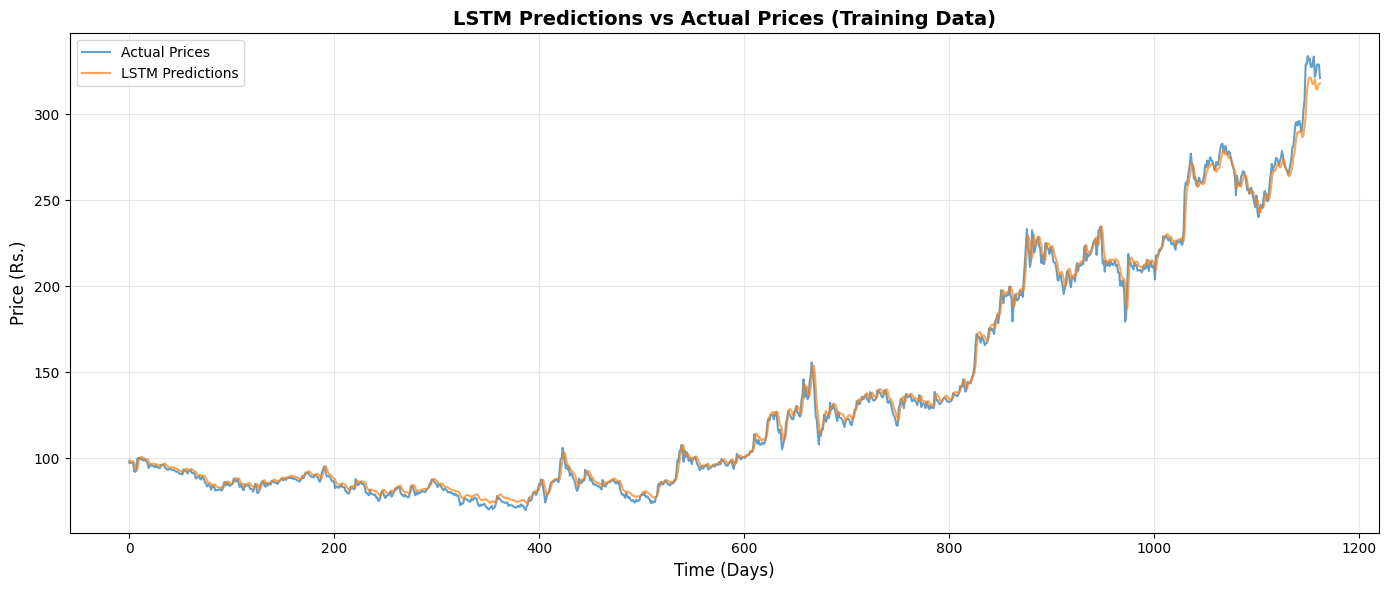


📊 Training Performance Metrics:
MSE: 17.6911
MAE: 2.9246


In [9]:
# Test Prediction on Training Data (Sanity Check)
predictions = model.predict(X_train)
predictions = scaler.inverse_transform(predictions)
y_train_real = scaler.inverse_transform(y_train.reshape(-1, 1))

# Visualize Predictions vs Actual
plt.figure(figsize=(14, 6))
plt.plot(y_train_real, label='Actual Prices', linewidth=1.5, alpha=0.7)
plt.plot(predictions, label='LSTM Predictions', linewidth=1.5, alpha=0.7)
plt.title('LSTM Predictions vs Actual Prices (Training Data)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Price (Rs.)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate metrics
mse = np.mean((y_train_real - predictions)**2)
mae = np.mean(np.abs(y_train_real - predictions))
print(f"\n📊 Training Performance Metrics:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

In [10]:
# Save the Model
model.save('lstm_model.h5')
print("\n✅ Model saved as 'lstm_model.h5'")
print("\n📥 Download this file and place it in your project directory.")
print("Path: C:\\FYP\\AI-MarketForecasting-Using-GAN-PSX-data\\lstm_model.h5")


✅ Model saved as 'lstm_model.h5'

📥 Download this file and place it in your project directory.
Path: C:\FYP\AI-MarketForecasting-Using-GAN-PSX-data\lstm_model.h5


In [11]:
# Optional: Make a Single Prediction (Example)
# Take the last 60 days and predict the next day
last_60_days = scaled_data[-LOOKBACK_WINDOW:]
last_60_days_reshaped = last_60_days.reshape(1, LOOKBACK_WINDOW, 1)

predicted_price_scaled = model.predict(last_60_days_reshaped, verbose=0)
predicted_price = scaler.inverse_transform(predicted_price_scaled)

print(f"\n🔮 Next Day Price Prediction: Rs. {predicted_price[0][0]:.2f}")
print(f"Current Price (Last Known): Rs. {close_prices[-1][0]:.2f}")
change = predicted_price[0][0] - close_prices[-1][0]
print(f"Predicted Change: Rs. {change:+.2f} ({(change/close_prices[-1][0])*100:+.2f}%)")


🔮 Next Day Price Prediction: Rs. 314.23
Current Price (Last Known): Rs. 321.18
Predicted Change: Rs. -6.95 (-2.16%)


In [12]:
# Add this cell at the END of your LSTM_Train.ipynb notebook (after training)
import joblib

# Save the scaler for production use
joblib.dump(scaler, 'lstm_model_scaler.pkl')
print("✅ Scaler saved as lstm_model_scaler.pkl")

✅ Scaler saved as lstm_model_scaler.pkl
